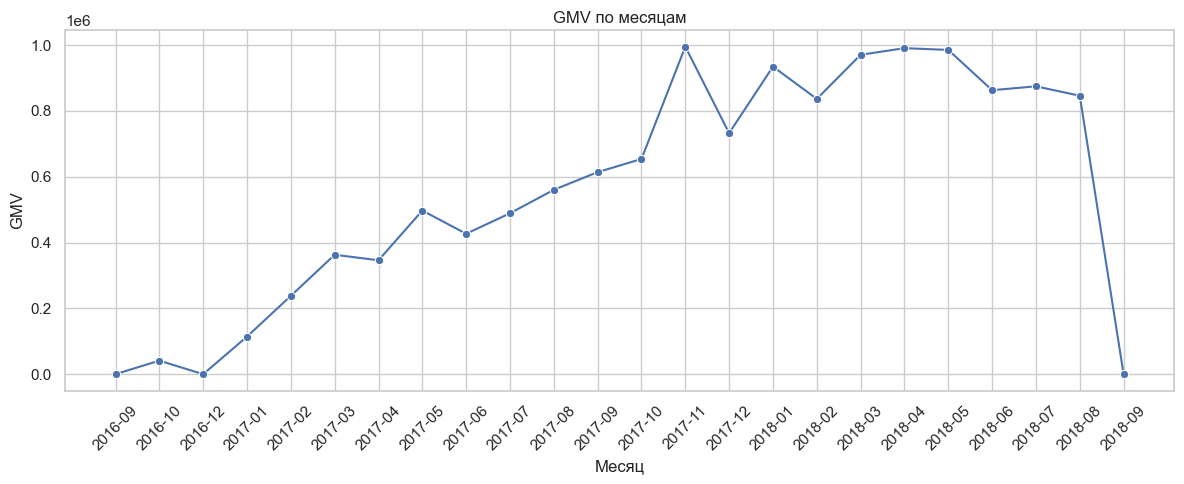

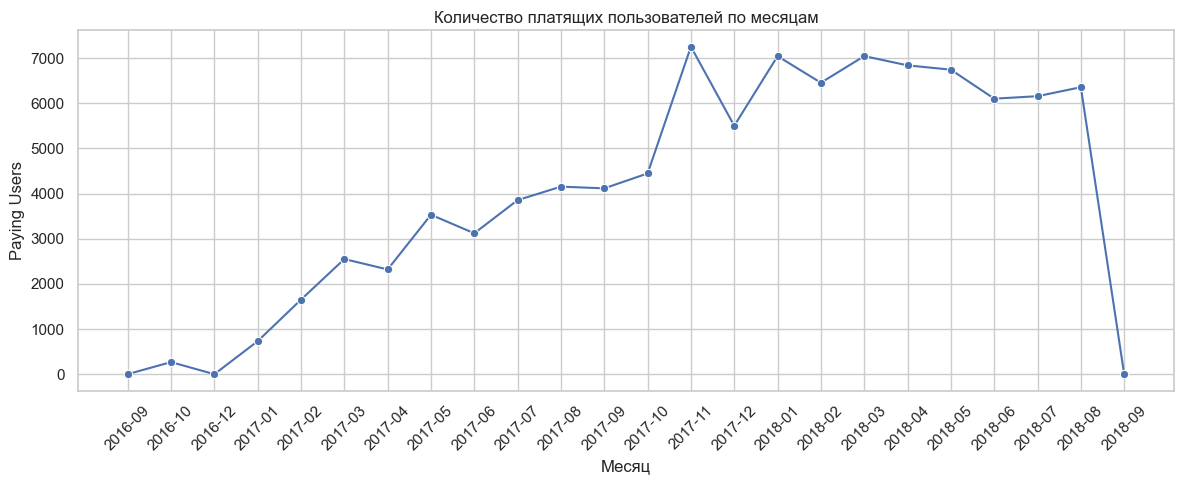

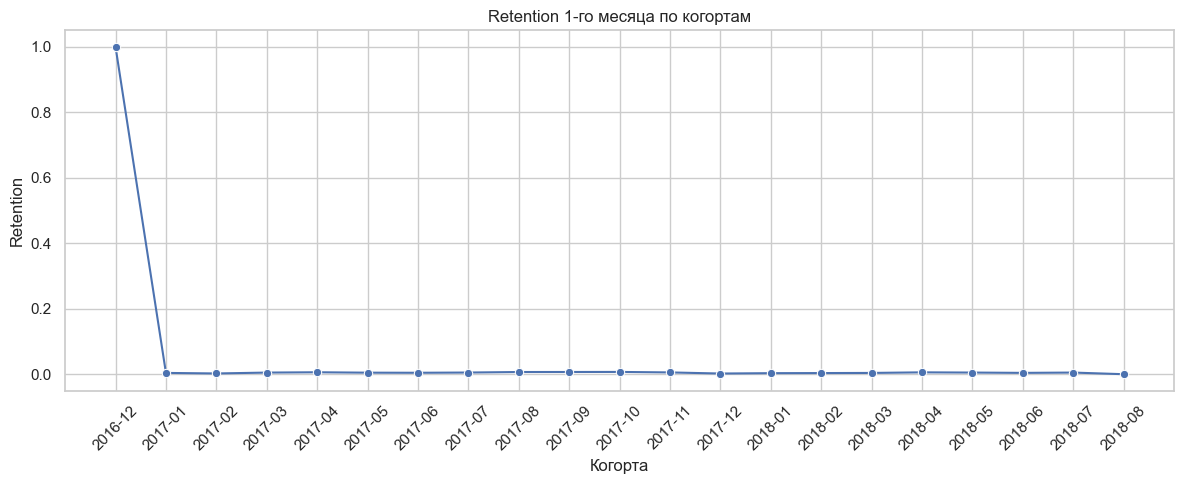

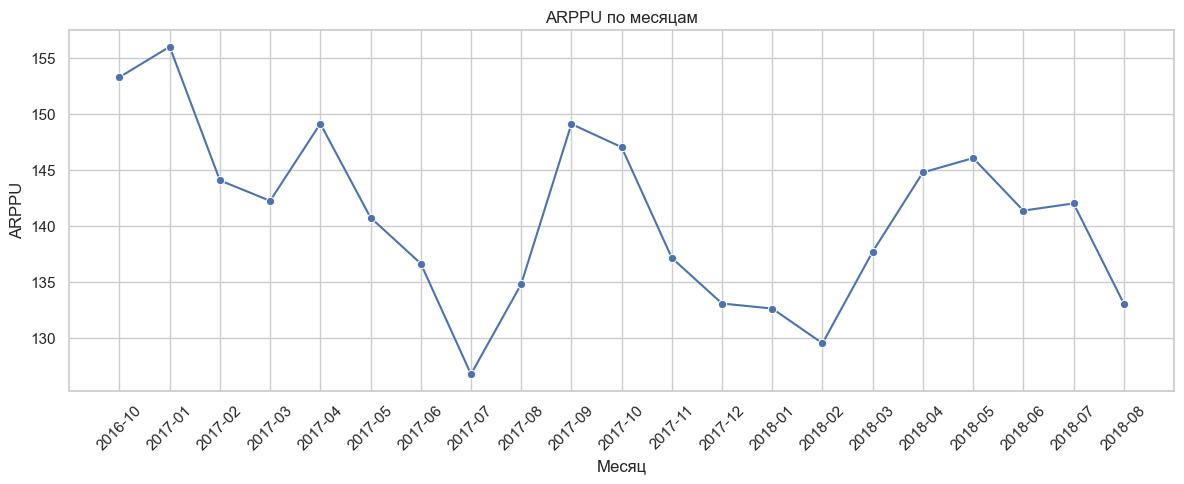

GMV по месяцам:
  order_month        gmv
0     2016-09     207.86
1     2016-10   41234.67
2     2016-12      10.90
3     2017-01  114197.09
4     2017-02  238034.46 

Платящие пользователи по месяцам:
  order_month  paying_users
0     2016-09             2
1     2016-10           269
2     2016-12             1
3     2017-01           732
4     2017-02          1652 

Retention 1-го месяца по когортам:
   cohort_month  retention
11      2016-12   1.000000
13      2017-01   0.004104
31      2017-02   0.002426
49      2017-03   0.005108
67      2017-04   0.006084 

ARPPU по месяцам:
  order_month       arppu
1     2016-10  153.288736
3     2017-01  156.006954
4     2017-02  144.088656
5     2017-03  142.262709
6     2017-04  149.146816


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

df = (
    orders
    .merge(customers, on='customer_id', how='inner')
    .merge(order_items, on='order_id', how='inner')
)

valid_statuses = ['approved', 'shipped', 'delivered']
df = df[df['order_status'].isin(valid_statuses)].copy()

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

max_date = df['order_purchase_timestamp'].max()
last_full_month = (max_date - pd.offsets.MonthBegin(1)).to_period('M')

df = df[df['order_month'] <= last_full_month].copy()

gmv = (
    df.groupby('order_month', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'gmv'})
    .sort_values('order_month')
)

paying_users = (
    df.groupby('order_month', as_index=False)['customer_unique_id']
    .nunique()
    .rename(columns={'customer_unique_id': 'paying_users'})
    .sort_values('order_month')
)

arppu = (
    gmv.merge(paying_users, on='order_month', how='inner')
    .sort_values('order_month')
)

arppu['arppu'] = arppu['gmv'] / arppu['paying_users']

arppu_plot = arppu[arppu['paying_users'] >= 100].copy()

first_order = (
    df.groupby('customer_unique_id', as_index=False)['order_month']
    .min()
    .rename(columns={'order_month': 'cohort_month'})
)

df = df.merge(first_order, on='customer_unique_id', how='inner')

df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12
    + (df['order_month'].dt.month - df['cohort_month'].dt.month)
)

cohort_data = (
    df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_unique_id': 'users_cnt'})
)

cohort_size = (
    cohort_data[cohort_data['cohort_index'] == 0][['cohort_month', 'users_cnt']]
    .rename(columns={'users_cnt': 'cohort_size'})
)

cohort_data = cohort_data.merge(cohort_size, on='cohort_month', how='left')
cohort_data['retention'] = cohort_data['users_cnt'] / cohort_data['cohort_size']

retention_1 = (
    cohort_data[cohort_data['cohort_index'] == 1][['cohort_month', 'retention']]
    .sort_values('cohort_month')
    .copy()
)

gmv_plot = gmv.copy()
paying_users_plot = paying_users.copy()

gmv_plot['order_month'] = gmv_plot['order_month'].astype(str)
paying_users_plot['order_month'] = paying_users_plot['order_month'].astype(str)
arppu_plot['order_month'] = arppu_plot['order_month'].astype(str)
retention_1['cohort_month'] = retention_1['cohort_month'].astype(str)

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

plt.figure()
sns.lineplot(data=gmv_plot, x='order_month', y='gmv', marker='o')
plt.title('GMV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('GMV')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.lineplot(data=paying_users_plot, x='order_month', y='paying_users', marker='o')
plt.title('Количество платящих пользователей по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Paying Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.lineplot(data=retention_1, x='cohort_month', y='retention', marker='o')
plt.title('Retention 1-го месяца по когортам')
plt.xlabel('Когорта')
plt.ylabel('Retention')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
sns.lineplot(data=arppu_plot, x='order_month', y='arppu', marker='o')
plt.title('ARPPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPPU')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('GMV по месяцам:')
print(gmv.head(), '\n')

print('Платящие пользователи по месяцам:')
print(paying_users.head(), '\n')

print('Retention 1-го месяца по когортам:')
print(retention_1.head(), '\n')

print('ARPPU по месяцам:')
print(arppu_plot[['order_month', 'arppu']].head())

Для максимизации прибыли маркетплейса были выбраны 5 ключевых продуктовых метрик:

- GMV (Gross Merchandise Value) — отражает общий объем продаж маркетплейса и является основной метрикой роста бизнеса.
- Paying Users — показывает количество пользователей, которым продукт доставляет ценность, так как они совершают покупку.
- Conversion Rate — отражает заинтересованность новых пользователей в продукте. На текущих данных эта метрика не рассчитывается из-за отсутствия информации о трафике, однако она является критически важной для анализа эффективности привлечения.
- Retention — отражает вовлеченность клиента и его возвращаемость в продукт, показывая, формируется ли повторное поведение.
- ARPPU (Average Revenue Per Paying User) — отражает денежное выражение вовлеченности клиента и показывает, сколько в среднем приносит один платящий пользователь.

Вывод по результатам анализа:

Перед проведением анализа из выборки был исключен последний неполный месяц, чтобы избежать искажения динамики метрик.

По графикам видно, что GMV и количество платящих пользователей демонстрируют рост, что говорит о способности маркетплейса привлекать новых клиентов и увеличивать объем продаж. При этом ARPPU остается относительно стабильным, что свидетельствует о нормальном уровне среднего чека и отсутствии проблем с монетизацией на уровне одной покупки.

В то же время ключевой проблемой продукта является крайне низкий retention. Даже с учетом возможных ограничений данных уровень удержания остается минимальным, что указывает на отсутствие повторного покупательского поведения.

Это означает, что рост бизнеса обеспечивается преимущественно за счет привлечения новых пользователей, а не за счет их удержания. Такая модель роста является неустойчивой, так как требует постоянных вложений в привлечение и не формирует долгосрочную ценность клиента.

Таким образом, для максимизации прибыли продакт-команде необходимо в первую очередь сосредоточиться на увеличении retention и доли повторных покупок, так как именно эти показатели являются ключевыми драйверами устойчивого роста бизнеса.